<a href="https://colab.research.google.com/github/ibrahim076/MACHINE-LEARNING-24BAD035/blob/main/EX03_SCENARIO-1%2C2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multilinear & Polynomial Regression Analysis


### Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


---
# SCENARIO 1: Multilinear Regression on Student Performance
---

### Load and Explore Dataset

In [4]:

df = pd.read_csv("StudentsPerformance.csv")

print("Dataset Shape:", df.shape)
print(" ")
print(df.head())
print(" ")
print(df.info())

Dataset Shape: (1000, 8)
 
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              

### Create Target Variable


In [5]:
df["final_score"] = (df["math score"] + df["reading score"] + df["writing score"]) / 3

print("Target Variable Statistics:")
print(df["final_score"].describe())

Target Variable Statistics:
count    1000.000000
mean       67.770667
std        14.257326
min         9.000000
25%        58.333333
50%        68.333333
75%        77.666667
max       100.000000
Name: final_score, dtype: float64


### Simulate Additional Features
Add study hours, attendance, and sleep hours for demonstration

In [6]:
np.random.seed(42)

df["study_hours"] = np.random.randint(1, 8, size=len(df))
df["attendance"] = np.random.randint(60, 100, size=len(df))
df["sleep_hours"] = np.random.randint(4, 9, size=len(df))

print("Updated Dataset with Simulated Features:")
print(df.head())

Updated Dataset with Simulated Features:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  \
0                    none          72             72             74   
1               completed          69             90             88   
2                    none          90             95             93   
3                    none          47             57             44   
4                    none          76             78             75   

   final_score  study_hours  attendance  sleep_hours  
0    72.666667            7          76            6  
1

### Feature and Target Selection

In [7]:

X = df.drop(columns=["math score", "reading score", "writing score", "final_score"])
y = df["final_score"]

print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

Features (X):
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  study_hours  attendance  sleep_hours  
0                    none            7          76            6  
1               completed            4          64            5  
2                    none            5          88            7  
3                    none            7          63            5  
4                    none            3          69            7  

Target (y):
0    72.666667
1    82.333333
2    92.666667
3    49.333333
4    76.333333
Name: final_score, dtype: float64


### Identify Feature Types

In [8]:
categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

Categorical Features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
Numerical Features: ['study_hours', 'attendance', 'sleep_hours']


### Create Preprocessing Pipeline

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully")

Preprocessing pipeline created successfully


### Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 800
Test set size: 200


### Train Multilinear Regression Model

In [11]:
model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)
print("Linear Regression model trained successfully")

Linear Regression model trained successfully


### Make Predictions

In [12]:
y_pred = model.predict(X_test)

print("Sample Predictions vs Actual:")
comparison_df = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10],
    "Difference": y_test.values[:10] - y_pred[:10]
})
print(comparison_df)

Sample Predictions vs Actual:
      Actual  Predicted  Difference
0  87.000000  70.501918   16.498082
1  64.000000  66.508131   -2.508131
2  75.000000  73.119541    1.880459
3  74.666667  56.164713   18.501953
4  81.666667  78.985590    2.681076
5  78.000000  59.347932   18.652068
6  67.333333  64.345477    2.987856
7  59.000000  74.162399  -15.162399
8  77.333333  57.183186   20.150148
9  48.666667  70.275875  -21.609208


### Model Evaluation

In [13]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("="*50)
print("LINEAR REGRESSION MODEL PERFORMANCE")
print("="*50)
print(f"Mean Squared Error (MSE)  : {mse:.4f}")
print(f"Root Mean Squared Error   : {rmse:.4f}")
print(f"R² Score                  : {r2:.4f}")
print("="*50)

LINEAR REGRESSION MODEL PERFORMANCE
Mean Squared Error (MSE)  : 181.8175
Root Mean Squared Error   : 13.4840
R² Score                  : 0.1518


### Analyze Regression Coefficients

In [14]:

feature_names = (
    numerical_features +
    model.named_steps["preprocessing"]
         .transformers_[1][1]
         .get_feature_names_out(categorical_features).tolist()
)

coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

print("\nTop 10 Feature Coefficients:")
print(coef_df.head(10))


Top 10 Feature Coefficients:
                                          Feature  Coefficient
13                                 lunch_standard     9.210343
7                          race/ethnicity_group E     6.147183
6                          race/ethnicity_group D     3.851054
8   parental level of education_bachelor's degree     3.480108
10    parental level of education_master's degree     1.920988
5                          race/ethnicity_group C     1.047609
0                                     study_hours    -0.061857
4                          race/ethnicity_group B    -0.100344
2                                     sleep_hours    -0.210613
1                                      attendance    -0.738503


### Ridge Regression (L2 Regularization)

In [15]:
ridge = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])

ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print("Ridge Regression Performance:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")
print(f"R² Score: {r2_score(y_test, y_pred_ridge):.4f}")

Ridge Regression Performance:
RMSE: 13.4893
R² Score: 0.1512


### Lasso Regression

In [16]:
lasso = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regressor", Lasso(alpha=0.01, max_iter=10000))
])

lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print("Lasso Regression Performance:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f}")
print(f"R² Score: {r2_score(y_test, y_pred_lasso):.4f}")

Lasso Regression Performance:
RMSE: 13.4975
R² Score: 0.1501


#### Predicted vs Actual Scores

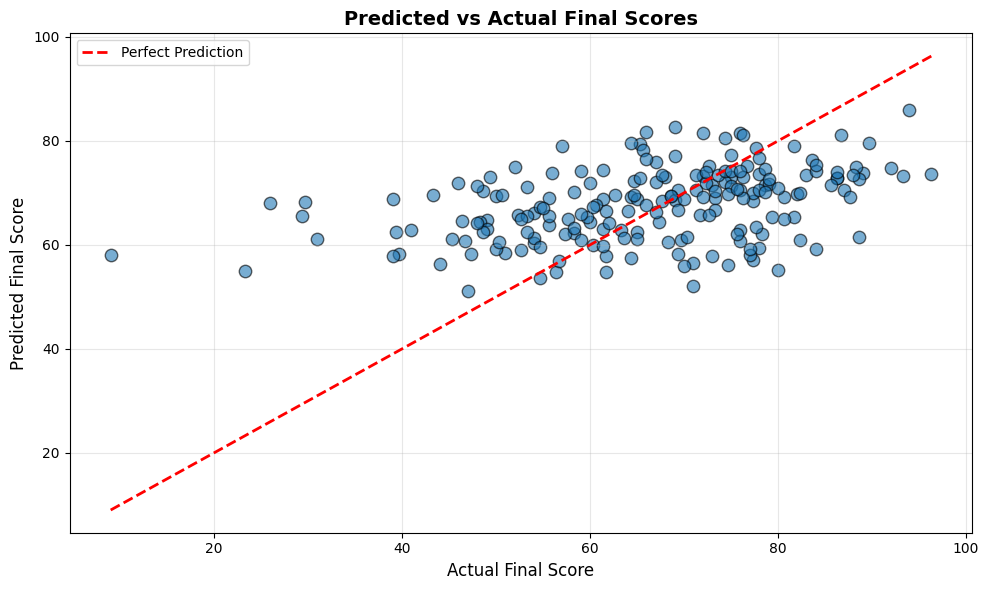

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Final Score", fontsize=12)
plt.ylabel("Predicted Final Score", fontsize=12)
plt.title("Predicted vs Actual Final Scores", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Top Feature Influences (Coefficient Magnitude)

<Figure size 1200x600 with 0 Axes>

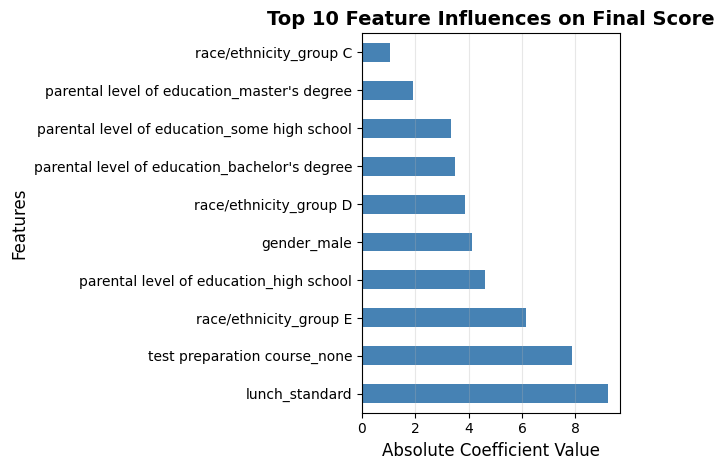

In [18]:
plt.figure(figsize=(12, 6))
top_features = coef_df.set_index("Feature").abs().sort_values(
    by="Coefficient", ascending=False
).head(10)

top_features.plot(kind="barh", legend=False, color='steelblue')
plt.xlabel("Absolute Coefficient Value", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.title("Top 10 Feature Influences on Final Score", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

#### Residual Distribution

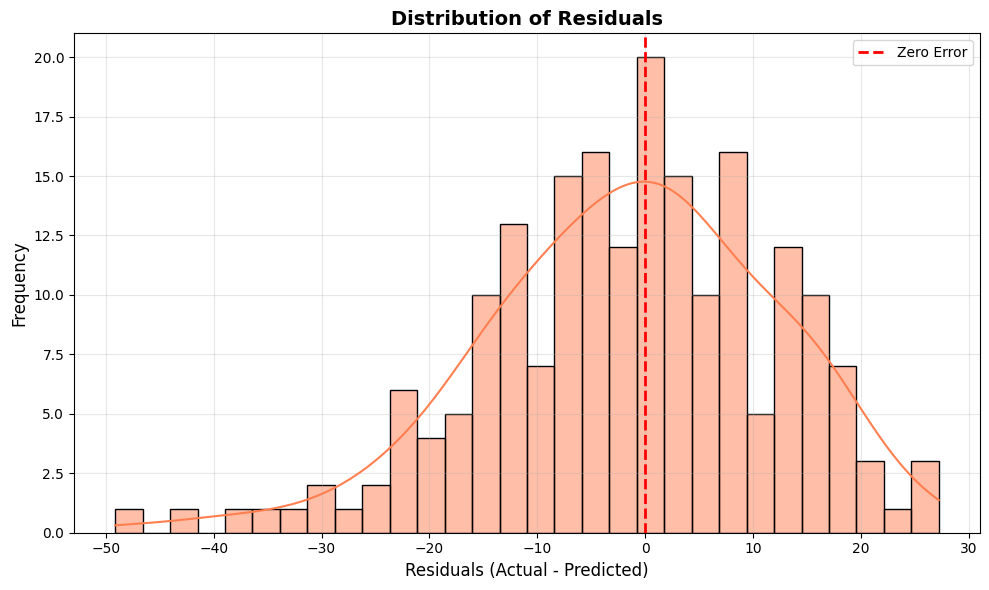

Mean Residual: -1.6012
Std Residual: 13.4222


In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='coral', bins=30)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.xlabel("Residuals (Actual - Predicted)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Residuals", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Std Residual: {residuals.std():.4f}")

---
# SCENARIO 2: Polynomial Regression on Auto MPG Dataset
---

### Load Auto MPG Dataset

In [20]:
df = pd.read_csv("auto-mpg.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())

Dataset Shape: (398, 9)

First 5 rows:
    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    

### Data Cleaning

In [21]:

df["horsepower"] = df["horsepower"].replace("?", np.nan)
df["horsepower"] = df["horsepower"].astype(float)

print("Missing values in horsepower:", df["horsepower"].isna().sum())

Missing values in horsepower: 6


### Handle Missing Values

In [22]:
mean_hp = df["horsepower"].mean()
df["horsepower"].fillna(mean_hp, inplace=True)

print(f"Filled missing values with mean: {mean_hp:.2f}")
print("Missing values after filling:", df["horsepower"].isna().sum())

Filled missing values with mean: 104.47
Missing values after filling: 0


/tmp/ipykernel_240/3481358847.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["horsepower"].fillna(mean_hp, inplace=True)


### Feature and Target Selection

In [23]:
X = df[["horsepower"]]
y = df["mpg"]

print("Feature (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nTarget statistics:")
print(y.describe())

Feature (X) shape: (398, 1)
Target (y) shape: (398,)

Target statistics:
count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64


### Train-Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 318
Test set size: 80


### Feature Scaling

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")

Feature scaling completed


### Polynomial Regression Function

In [26]:
def polynomial_model(degree):
    """
    Train a polynomial regression model of given degree

    Parameters:
    -----------
    degree : int
        Degree of polynomial features

    Returns:
    --------
    model : LinearRegression
        Trained model
    poly : PolynomialFeatures
        Polynomial feature transformer
    mse, rmse, r2 : float
        Evaluation metrics
    """
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return model, poly, mse, rmse, r2

print("Polynomial regression function defined")

Polynomial regression function defined


### Train Models with Different Polynomial Degrees

In [27]:
results = {}

degrees = [1, 2, 3, 4, 5]

print("Training polynomial models...\n")
for d in degrees:
    model, poly, mse, rmse, r2 = polynomial_model(d)
    results[d] = {"MSE": mse, "RMSE": rmse, "R²": r2}
    print(f"Degree {d}: RMSE={rmse:.4f}, R²={r2:.4f}")

results_df = pd.DataFrame(results).T
print("\n" + "="*60)
print("POLYNOMIAL REGRESSION RESULTS")
print("="*60)
print(results_df)
print("="*60)

Training polynomial models...

Degree 1: RMSE=4.3762, R²=0.6438
Degree 2: RMSE=3.7096, R²=0.7441
Degree 3: RMSE=3.7166, R²=0.7431
Degree 4: RMSE=3.7574, R²=0.7374
Degree 5: RMSE=3.8294, R²=0.7273

POLYNOMIAL REGRESSION RESULTS
         MSE      RMSE        R²
1  19.151211  4.376210  0.643807
2  13.760855  3.709563  0.744062
3  13.813374  3.716635  0.743086
4  14.118024  3.757396  0.737419
5  14.664344  3.829405  0.727258


### 2.9 Model Comparison Table

| **Degree** | **Behavior**                    | **Typical Outcome**        |
|------------|---------------------------------|----------------------------|
| 1          | Linear fit                      | Underfitting               |
| 2          | Quadratic curve                 | Good bias-variance balance |
| 3          | Cubic curve                     | Better fit                 |
| 4          | Higher-order polynomial         | Overfitting risk           |
| 5          | Very complex curve              | High overfitting risk      |

### Visualization: Polynomial Regression Curves

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


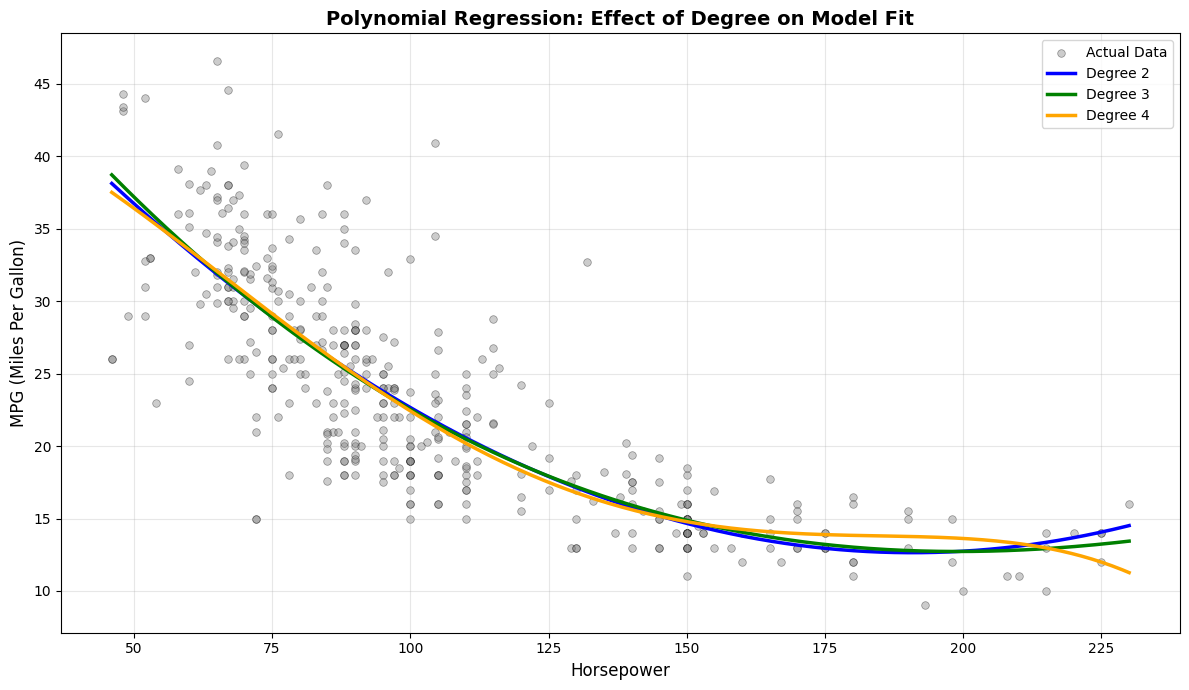

In [28]:

X_range = np.linspace(X.min().values[0], X.max().values[0], 300).reshape(-1, 1)
X_range_scaled = scaler.transform(X_range)

plt.figure(figsize=(12, 7))
plt.scatter(X, y, alpha=0.4, s=30, c='gray', label="Actual Data", edgecolors='k', linewidths=0.5)

colors = ['blue', 'green', 'orange', 'red', 'purple']
for i, d in enumerate([ 2, 3, 4]):
    poly = PolynomialFeatures(d)
    X_poly = poly.fit_transform(X_train_scaled)
    model = LinearRegression()
    model.fit(X_poly, y_train)

    y_curve = model.predict(poly.transform(X_range_scaled))
    plt.plot(X_range, y_curve, label=f"Degree {d}", linewidth=2.5, color=colors[i])

plt.xlabel("Horsepower", fontsize=12)
plt.ylabel("MPG (Miles Per Gallon)", fontsize=12)
plt.title("Polynomial Regression: Effect of Degree on Model Fit", fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Ridge Regression for Overfitting Control

In [29]:

poly_high = PolynomialFeatures(degree=5)

X_train_poly = poly_high.fit_transform(X_train_scaled)
X_test_poly = poly_high.transform(X_test_scaled)


alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

print("\n" + "="*70)
print("RIDGE REGRESSION WITH DEGREE 5 POLYNOMIAL")
print("="*70)
print(f"{'Alpha':<10} {'RMSE':<15} {'R² Score':<15}")
print("-"*70)

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_poly, y_train)
    y_pred_ridge = ridge.predict(X_test_poly)

    rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    r2_ridge = r2_score(y_test, y_pred_ridge)

    print(f"{alpha:<10} {rmse_ridge:<15.4f} {r2_ridge:<15.4f}")

print("="*70)


ridge_optimal = Ridge(alpha=1.0)
ridge_optimal.fit(X_train_poly, y_train)
y_pred_ridge_optimal = ridge_optimal.predict(X_test_poly)

print(f"\nOptimal Ridge Regression (alpha=1.0):")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge_optimal)):.4f}")
print(f"R² Score: {r2_score(y_test, y_pred_ridge_optimal):.4f}")


RIDGE REGRESSION WITH DEGREE 5 POLYNOMIAL
Alpha      RMSE            R² Score       
----------------------------------------------------------------------
0.01       3.8292          0.7273         
0.1        3.8273          0.7276         
1.0        3.8107          0.7299         
10.0       3.7509          0.7383         
100.0      4.0354          0.6971         

Optimal Ridge Regression (alpha=1.0):
RMSE: 3.8107
R² Score: 0.7299
